In [1]:
# -*- coding: utf-8 -*-
"""
Clean runnable script exported from ViHBC_run_nichecompass.ipynb.
Redundant commented-out legacy/v2 cells removed.
"""

# ===== Notebook Cell 0 =====
# ===== Cell 1: 强制只使用 GPU 0（必须放在最前面） =====
import os

# 这两行必须在 import torch / import nichecompass 之前
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print("CUDA_VISIBLE_DEVICES =", os.environ["CUDA_VISIBLE_DEVICES"])
print("现在 notebook 只会看到 1 块 GPU，并且它对应物理 GPU 0")

# ===== Notebook Cell 1 =====
# ===== Cell 2: 验证 GPU 是否锁定成功 =====
import sys
import torch

LOCAL_SRC = "/home/zhangjunyi/xiangmu/nichecompass-main/src"
if LOCAL_SRC not in sys.path:
    sys.path.insert(0, LOCAL_SRC)

import nichecompass as nc

print("nichecompass loaded from:")
print(nc.__file__)

print("\ntorch.cuda.is_available() =", torch.cuda.is_available())
print("torch.cuda.device_count() =", torch.cuda.device_count())

if torch.cuda.is_available():
    print("当前可见 GPU 名称 =", torch.cuda.get_device_name(0))
    print("当前可见 GPU 编号 = 0")
else:
    print("没有检测到 GPU，说明前面环境或内核有问题。")

assert nc.__file__.startswith("/home/zhangjunyi/xiangmu/nichecompass-main/src"), \
    "当前导入的不是你本地修改后的 NicheCompass，请先重启 kernel 再运行。"

# ===== Notebook Cell 3 =====
import sys
sys.path.insert(0, "/home/zhangjunyi/xiangmu/nichecompass-main/src")

import nichecompass as nc
print(nc.__file__)

# ===== Notebook Cell 5 =====
# ===== Cell 2: 依赖 + 四元组 =====
import warnings
warnings.filterwarnings("ignore")

from io import StringIO
from pathlib import Path

import decoupler as dc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import squidpy as sq
import torch
from sklearn.preprocessing import MinMaxScaler

tmcn_csv = """TMCN_Name,Source_Pathways,Source_Genes,Target_Genes,Biologic_Meaning
TMCN_Lactate_Axis,"EGFR,PI3K,Hypoxia","HK2,LDHA,LDHB,SLC16A3","SLC16A1,HCAR1",乳酸_肿瘤酸化与代谢重生
TMCN_Adenosine_Axis,"Hypoxia","MYC,ENTPD1,NT5E","ADORA1,ADORA2A,ADORA2B,ADORA3",腺苷_强效免疫抑制与血管生成
TMCN_PGE2_Axis,"NFkB,JAK-STAT","PTGS2,PTGES","PTGER1,PTGER2,PTGER4",前列腺素E2_炎症微环境重塑
TMCN_Glutamine_Axis,"JAK-STAT,TGFb","MYC,GLUL","SLC1A5,SLC38A2",谷氨酰胺_基质-肿瘤代谢共生(寄生)
TMCN_Succinate_Axis,"Hypoxia","EGLN1,TET2,SLC25A10","SUCNR1",琥珀酸_琥珀酸介导的巨噬细胞极化
"""

tmcn_df = pd.read_csv(StringIO(tmcn_csv))
display(tmcn_df)

AXES = [x.replace("TMCN_", "").replace("_Axis", "") for x in tmcn_df["TMCN_Name"].tolist()]
print("Axes:", AXES)

# ===== Notebook Cell 7 =====
# ===== Cell 3: 工具函数（最终稳定版，不再使用 scanpy HVG） =====

def split_items(x):
    return [i.strip() for i in str(x).split(",") if i.strip()]

def normalize_pathway_name(x):
    return x.strip().replace("-", "_").replace(" ", "_")

def get_valid_genes(adata, genes):
    return [g for g in genes if g in adata.var_names]

def sparse_or_dense_mean_by_genes(adata, genes):
    """
    计算一组基因在每个 spot/cell 中的平均表达。
    支持 sparse / dense。
    """
    valid_genes = get_valid_genes(adata, genes)
    if len(valid_genes) == 0:
        return np.zeros(adata.n_obs, dtype=float)

    X = adata[:, valid_genes].X
    if sp.issparse(X):
        return np.asarray(X.mean(axis=1)).reshape(-1)
    return np.asarray(X).mean(axis=1).reshape(-1)

def minmax_1d(x):
    x = np.asarray(x).reshape(-1, 1)
    return MinMaxScaler().fit_transform(x).reshape(-1)

def build_metabolic_net_from_quartets(tmcn_df, adata):
    """
    把四元组中的 Source_Genes 构造成 AUCell 需要的网络格式。
    """
    rows = []
    for _, row in tmcn_df.iterrows():
        axis = row["TMCN_Name"].replace("TMCN_", "").replace("_Axis", "")
        for g in split_items(row["Source_Genes"]):
            if g in adata.var_names:
                rows.append({"source": axis, "target": g})
    return pd.DataFrame(rows)

def collect_forced_genes(tmcn_df):
    """
    收集必须保留的四元组基因：
    Source_Genes ∪ Target_Genes
    """
    forced = set()
    for _, row in tmcn_df.iterrows():
        forced.update(split_items(row["Source_Genes"]))
        forced.update(split_items(row["Target_Genes"]))
    return forced

def compute_tmcn_scores(adata_full, tmcn_df):
    """
    阶段 1：在全量 adata 上计算：
    1. PROGENy pathway activity
    2. AUCell machinery activity
    3. Sender / Receiver 综合得分
    """
    # ---------- 步骤 1.1：PROGENy ----------
    net_progeny = dc.get_progeny(organism="human", top=500)
    dc.run_mlm(
        mat=adata_full,
        net=net_progeny,
        source="source",
        target="target",
        weight="weight",
        verbose=False,
        use_raw=False,
    )

    df_A = dc.get_acts(adata_full, obsm_key="mlm_estimate").to_df()
    df_A.columns = [f"PROGENy_{normalize_pathway_name(c)}" for c in df_A.columns]

    # ---------- 步骤 1.2：AUCell ----------
    metabolic_net = build_metabolic_net_from_quartets(tmcn_df, adata_full)
    dc.run_aucell(
        mat=adata_full,
        net=metabolic_net,
        source="source",
        target="target",
        min_n=1,
        verbose=False,
        use_raw=False,
    )

    df_B = dc.get_acts(adata_full, obsm_key="aucell_estimate").to_df()
    df_B.columns = [f"AUCell_{c}" for c in df_B.columns]

    # ---------- 步骤 1.3：归一化 ----------
    df_A_scaled = pd.DataFrame(
        MinMaxScaler().fit_transform(df_A),
        index=df_A.index,
        columns=df_A.columns
    )

    df_B_scaled = pd.DataFrame(
        MinMaxScaler().fit_transform(df_B),
        index=df_B.index,
        columns=df_B.columns
    )

    # ---------- 计算 Sender / Receiver ----------
    for _, row in tmcn_df.iterrows():
        axis = row["TMCN_Name"].replace("TMCN_", "").replace("_Axis", "")
        source_pathways = [normalize_pathway_name(x) for x in split_items(row["Source_Pathways"])]
        target_genes = split_items(row["Target_Genes"])

        progeny_cols = [f"PROGENy_{p}" for p in source_pathways if f"PROGENy_{p}" in df_A_scaled.columns]
        aucell_col = f"AUCell_{axis}"

        if len(progeny_cols) == 0:
            raise ValueError(f"{axis}: 没找到 PROGENy 列，请检查 Source_Pathways 名称。")

        if aucell_col not in df_B_scaled.columns:
            raise ValueError(f"{axis}: 没找到 AUCell 列 {aucell_col}。")

        sender_score = df_A_scaled[progeny_cols].mean(axis=1) * df_B_scaled[aucell_col]
        receiver_score = minmax_1d(sparse_or_dense_mean_by_genes(adata_full, target_genes))

        adata_full.obs[f"{axis}_Sender_Score"] = sender_score.values
        adata_full.obs[f"{axis}_Receiver_Score"] = receiver_score

    return adata_full, df_A, df_B, df_A_scaled, df_B_scaled


# =========================
# 新增：稳定的矩阵清洗函数
# =========================
def sanitize_matrix(mat):
    """
    把矩阵中的 nan / inf 清理掉。
    """
    if sp.issparse(mat):
        mat = mat.copy().tocsr()
        mat.data = np.nan_to_num(mat.data, nan=0.0, posinf=0.0, neginf=0.0)
        return mat
    else:
        return np.nan_to_num(np.asarray(mat), nan=0.0, posinf=0.0, neginf=0.0)

def get_matrix_for_hvg(adata):
    """
    优先使用 counts layer；
    如果没有，就使用 X。
    返回清洗后的矩阵和来源名字。
    """
    if "counts" in adata.layers:
        X = sanitize_matrix(adata.layers["counts"])
        source_name = "counts"
    else:
        X = sanitize_matrix(adata.X)
        source_name = "X"
    return X, source_name

def compute_gene_dispersion_manual(X):
    """
    手动计算每个基因的离散度（dispersion），避免 scanpy HVG 的 binning 报错。
    dispersion = variance / mean
    """
    if sp.issparse(X):
        X = X.tocsr()
        gene_mean = np.asarray(X.mean(axis=0)).reshape(-1)
        gene_mean_sq = np.asarray(X.multiply(X).mean(axis=0)).reshape(-1)
        gene_var = gene_mean_sq - gene_mean ** 2
    else:
        gene_mean = np.mean(X, axis=0)
        gene_var = np.var(X, axis=0)

    gene_mean = np.nan_to_num(gene_mean, nan=0.0, posinf=0.0, neginf=0.0)
    gene_var = np.nan_to_num(gene_var, nan=0.0, posinf=0.0, neginf=0.0)

    # 防止负数方差（数值误差）
    gene_var = np.maximum(gene_var, 0.0)

    # dispersion = variance / mean
    dispersion = gene_var / (gene_mean + 1e-8)
    dispersion = np.nan_to_num(dispersion, nan=0.0, posinf=0.0, neginf=0.0)

    return gene_mean, gene_var, dispersion

def select_top_hvg_manual(adata, n_top_genes=2000):
    """
    手动选择 HVG：
    - 不使用 scanpy.pp.highly_variable_genes
    - 直接按 dispersion 排名前 n_top_genes
    """
    X_hvg, source_name = get_matrix_for_hvg(adata)
    gene_mean, gene_var, dispersion = compute_gene_dispersion_manual(X_hvg)

    df_stats = pd.DataFrame({
        "gene": adata.var_names,
        "mean": gene_mean,
        "var": gene_var,
        "dispersion": dispersion
    })

    # 去掉完全无信息的基因
    df_stats = df_stats[(df_stats["mean"] >= 0) & np.isfinite(df_stats["dispersion"])].copy()

    # 按 dispersion 从大到小选前 n_top_genes
    df_stats = df_stats.sort_values("dispersion", ascending=False)
    hvg_genes = df_stats["gene"].head(n_top_genes).tolist()

    print(f"HVG 来源矩阵: {source_name}")
    print(f"可用于排序的基因数: {df_stats.shape[0]}")
    print(f"选出的 HVG 数: {len(hvg_genes)}")

    return set(hvg_genes), df_stats

def subset_hvg_plus_quartet_genes(adata_full, tmcn_df, n_top_genes=2000):
    """
    训练用基因子集：
    HVG(2000) ∪ 四元组基因
    """
    forced_genes = collect_forced_genes(tmcn_df)
    forced_genes = {g for g in forced_genes if g in adata_full.var_names}

    hvg_genes, df_hvg_stats = select_top_hvg_manual(adata_full, n_top_genes=n_top_genes)

    keep_genes = sorted(hvg_genes.union(forced_genes))
    adata_model = adata_full[:, keep_genes].copy()

    # 再清一次，确保模型输入无坏值
    adata_model.X = sanitize_matrix(adata_model.X)
    if "counts" in adata_model.layers:
        adata_model.layers["counts"] = sanitize_matrix(adata_model.layers["counts"])

    print(f"原始基因数: {adata_full.n_vars}")
    print(f"手动HVG数: {len(hvg_genes)}")
    print(f"强制保留四元组基因数: {len(forced_genes)}")
    print(f"最终训练基因数: {adata_model.n_vars}")

    if sp.issparse(adata_model.X):
        n_bad_x = np.sum(~np.isfinite(adata_model.X.data))
    else:
        n_bad_x = np.sum(~np.isfinite(np.asarray(adata_model.X)))
    print(f"adata_model.X 中非有限值个数: {int(n_bad_x)}")

    if "counts" in adata_model.layers:
        if sp.issparse(adata_model.layers["counts"]):
            n_bad_counts = np.sum(~np.isfinite(adata_model.layers["counts"].data))
        else:
            n_bad_counts = np.sum(~np.isfinite(np.asarray(adata_model.layers["counts"])))
        print(f"adata_model.layers['counts'] 中非有限值个数: {int(n_bad_counts)}")

    return adata_model, keep_genes, df_hvg_stats

def build_tmcn_graph(adata_model, axes, n_neighs=8):
    """
    阶段 2.2：构建代谢加权空间图
    """
    sq.gr.spatial_neighbors(
        adata_model,
        coord_type="generic",
        spatial_key="spatial",
        n_neighs=n_neighs
    )

    spatial_adj = adata_model.obsp["spatial_connectivities"].tocsr()

    S = np.vstack([adata_model.obs[f"{axis}_Sender_Score"].to_numpy() for axis in axes]).T
    R = np.vstack([adata_model.obs[f"{axis}_Receiver_Score"].to_numpy() for axis in axes]).T

    row_idx, col_idx = spatial_adj.nonzero()
    base_weights = np.asarray(spatial_adj[row_idx, col_idx]).reshape(-1)

    metabolic_affinity = np.sum(S[row_idx] * R[col_idx], axis=1)
    edge_weights = np.clip(base_weights * metabolic_affinity, a_min=1e-6, a_max=None)

    tmcn_adj = sp.csr_matrix(
        (edge_weights, (row_idx, col_idx)),
        shape=spatial_adj.shape
    )

    adata_model.obsp["tmcn_connectivities"] = tmcn_adj.maximum(tmcn_adj.T)
    return adata_model

def load_or_download_nichenet_cache(cache_dir):
    """
    读取或下载 NicheNet 先验，并缓存到本地。
    """
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    lr_path = cache_dir / "nichenet_lr_network.csv"
    lt_path = cache_dir / "nichenet_ligand_target_matrix.csv"

    if lr_path.exists() and lt_path.exists():
        print("从本地缓存加载 NicheNet...")
        gp_dict = nc.utils.extract_gp_dict_from_nichenet_lrt_interactions(
            species="human",
            version="v2",
            keep_target_genes_ratio=0.25,
            max_n_target_genes_per_gp=50,
            load_from_disk=True,
            lr_network_file_path=str(lr_path),
            ligand_target_matrix_file_path=str(lt_path),
            plot_gp_gene_count_distributions=False,
        )
    else:
        print("首次下载并缓存 NicheNet...")
        gp_dict = nc.utils.extract_gp_dict_from_nichenet_lrt_interactions(
            species="human",
            version="v2",
            keep_target_genes_ratio=0.25,
            max_n_target_genes_per_gp=50,
            save_to_disk=True,
            lr_network_file_path=str(lr_path),
            ligand_target_matrix_file_path=str(lt_path),
            plot_gp_gene_count_distributions=False,
        )
    return gp_dict

def annotate_tmcn_clusters(adata_model, axes, cluster_key="TMCN_Clusters", threshold=0.05):
    """
    阶段 3.2：根据 Sender*Receiver 强度给 cluster 打标签
    """
    rows = []
    for cluster in adata_model.obs[cluster_key].cat.categories:
        mask = adata_model.obs[cluster_key] == cluster
        row = {"Cluster": cluster}
        for axis in axes:
            intensity = (
                adata_model.obs.loc[mask, f"{axis}_Sender_Score"] *
                adata_model.obs.loc[mask, f"{axis}_Receiver_Score"]
            ).mean()
            row[f"{axis}_Intensity"] = intensity
        rows.append(row)

    df_cluster = pd.DataFrame(rows).set_index("Cluster")

    def label_cluster(row):
        best_axis = row.idxmax().replace("_Intensity", "")
        best_val = row.max()
        if best_val > threshold:
            return f"TMCN_{best_axis}_Axis"
        return "Background/Other_Niche"

    df_cluster["TMCN_Annotation"] = df_cluster.apply(label_cluster, axis=1)
    adata_model.obs["TMCN_Niche"] = adata_model.obs[cluster_key].map(
        df_cluster["TMCN_Annotation"].to_dict()
    )
    return adata_model, df_cluster
# ===== 新版 TMCN 注释工具函数：基于 spot 角色组成的 cluster 注释 =====

def get_quantile_thresholds(adata, axes, sender_q=0.75, receiver_q=0.75, min_positive=1e-8):
    """
    为每条 axis 计算 sender / receiver 的分位数阈值。
    只在 > min_positive 的正值上计算分位数，避免阈值变成 0。
    """

    thresholds = {}

    for axis in axes:
        sender_col = f"{axis}_Sender_Score"
        receiver_col = f"{axis}_Receiver_Score"

        sender_vals = adata.obs[sender_col].values
        receiver_vals = adata.obs[receiver_col].values

        sender_pos = sender_vals[sender_vals > min_positive]
        receiver_pos = receiver_vals[receiver_vals > min_positive]

        if len(sender_pos) == 0:
            sender_thr = np.inf
        else:
            sender_thr = float(np.quantile(sender_pos, sender_q))

        if len(receiver_pos) == 0:
            receiver_thr = np.inf
        else:
            receiver_thr = float(np.quantile(receiver_pos, receiver_q))

        thresholds[axis] = {
            "sender": sender_thr,
            "receiver": receiver_thr
        }

    return thresholds


def assign_spot_roles_by_axis(adata, axes, thresholds, min_positive=1e-8):
    """
    对每个 spot、每条 axis 赋予角色:
        Sender / Receiver / Dual / None
    并要求 score 本身也必须 > min_positive，防止 0 被判成高值。
    """
    for axis in axes:
        sender_col = f"{axis}_Sender_Score"
        receiver_col = f"{axis}_Receiver_Score"
        role_col = f"{axis}_Role"

        sender_thr = thresholds[axis]["sender"]
        receiver_thr = thresholds[axis]["receiver"]

        sender_vals = adata.obs[sender_col].values
        receiver_vals = adata.obs[receiver_col].values

        sender_high = (sender_vals > min_positive) & (sender_vals >= sender_thr)
        receiver_high = (receiver_vals > min_positive) & (receiver_vals >= receiver_thr)

        roles = np.full(adata.n_obs, "None", dtype=object)
        roles[np.where(sender_high & ~receiver_high)[0]] = "Sender"
        roles[np.where(~sender_high & receiver_high)[0]] = "Receiver"
        roles[np.where(sender_high & receiver_high)[0]] = "Dual"

        adata.obs[role_col] = pd.Categorical(
            roles,
            categories=["None", "Sender", "Receiver", "Dual"]
        )

    return adata

def summarize_cluster_axis_composition(adata, axes, cluster_key="TMCN_Clusters"):
    """
    统计每个 cluster 在每条 axis 上的组成信息:
        - Sender_Fraction
        - Receiver_Fraction
        - Dual_Fraction
        - Sender_Mean
        - Receiver_Mean
        - Mean_Intensity = mean(Sender * Receiver)

    返回:
        df_summary: 每个 cluster x axis 的详细表
    """
    rows = []

    clusters = adata.obs[cluster_key].cat.categories \
        if pd.api.types.is_categorical_dtype(adata.obs[cluster_key]) \
        else sorted(adata.obs[cluster_key].unique())

    for cluster in clusters:
        mask = adata.obs[cluster_key] == cluster
        n_spots = int(mask.sum())

        for axis in axes:
            sender_col = f"{axis}_Sender_Score"
            receiver_col = f"{axis}_Receiver_Score"
            role_col = f"{axis}_Role"

            sender_scores = adata.obs.loc[mask, sender_col]
            receiver_scores = adata.obs.loc[mask, receiver_col]
            roles = adata.obs.loc[mask, role_col]

            sender_fraction = float((roles == "Sender").mean()) if n_spots > 0 else 0.0
            receiver_fraction = float((roles == "Receiver").mean()) if n_spots > 0 else 0.0
            dual_fraction = float((roles == "Dual").mean()) if n_spots > 0 else 0.0
            none_fraction = float((roles == "None").mean()) if n_spots > 0 else 0.0

            sender_mean = float(sender_scores.mean()) if n_spots > 0 else 0.0
            receiver_mean = float(receiver_scores.mean()) if n_spots > 0 else 0.0
            mean_intensity = float((sender_scores * receiver_scores).mean()) if n_spots > 0 else 0.0

            rows.append({
                "Cluster": cluster,
                "Axis": axis,
                "N_Spots": n_spots,
                "Sender_Fraction": sender_fraction,
                "Receiver_Fraction": receiver_fraction,
                "Dual_Fraction": dual_fraction,
                "None_Fraction": none_fraction,
                "Sender_Mean": sender_mean,
                "Receiver_Mean": receiver_mean,
                "Mean_Intensity": mean_intensity
            })

    df_summary = pd.DataFrame(rows)
    return df_summary


def compute_cluster_axis_composition_score(
    df_summary,
    w_sender=0.35,
    w_receiver=0.35,
    w_dual=0.20,
    w_intensity=0.10
):
    """
    基于组成与强度计算每个 cluster-axis 的综合得分。
    """
    df_summary = df_summary.copy()

    df_summary["Axis_Composition_Score"] = (
        w_sender * df_summary["Sender_Fraction"] +
        w_receiver * df_summary["Receiver_Fraction"] +
        w_dual * df_summary["Dual_Fraction"] +
        w_intensity * df_summary["Mean_Intensity"]
    )

    return df_summary


def assign_cluster_tmcn_labels(
    adata,
    df_summary,
    cluster_key="TMCN_Clusters",
    score_col="Axis_Composition_Score",
    min_score_threshold=0.12,
    min_margin=0.02
):
    """
    为每个 cluster 指定主标签 / 次标签。

    规则:
    1. 对每个 cluster，按 Axis_Composition_Score 从高到低排序
    2. 最高分若 < min_score_threshold -> Background/Other_Niche
    3. 若第一名和第二名差距 < min_margin，也标成 Mixed_or_Ambiguous_Niche
       （你也可以以后改成主次双标签）
    4. 否则标成 TMCN_{best_axis}_Axis

    新增到 adata.obs 的列:
        - TMCN_Niche_v2
        - TMCN_Main_Axis
        - TMCN_Secondary_Axis
        - TMCN_Niche_Pattern
    """
    cluster_label_map = {}
    cluster_main_axis_map = {}
    cluster_second_axis_map = {}
    cluster_pattern_map = {}

    cluster_tables = []

    for cluster, sub in df_summary.groupby("Cluster"):
        sub = sub.sort_values(score_col, ascending=False).reset_index(drop=True)

        best_axis = sub.loc[0, "Axis"]
        best_score = float(sub.loc[0, score_col])

        if sub.shape[0] > 1:
            second_axis = sub.loc[1, "Axis"]
            second_score = float(sub.loc[1, score_col])
        else:
            second_axis = "None"
            second_score = 0.0

        margin = best_score - second_score

        # 判断这个 cluster 的模式
        best_sender_frac = float(sub.loc[0, "Sender_Fraction"])
        best_receiver_frac = float(sub.loc[0, "Receiver_Fraction"])
        best_dual_frac = float(sub.loc[0, "Dual_Fraction"])

        if best_dual_frac >= max(best_sender_frac, best_receiver_frac):
            niche_pattern = "Dual_Dominant"
        elif best_sender_frac > best_receiver_frac:
            niche_pattern = "Sender_Dominant"
        elif best_receiver_frac > best_sender_frac:
            niche_pattern = "Receiver_Dominant"
        else:
            niche_pattern = "Balanced"

        if best_score < min_score_threshold:
            niche_label = "Background/Other_Niche"
        elif margin < min_margin:
            niche_label = f"Mixed_or_Ambiguous_{best_axis}_Axis"
        else:
            niche_label = f"TMCN_{best_axis}_Axis"

        cluster_label_map[cluster] = niche_label
        cluster_main_axis_map[cluster] = best_axis
        cluster_second_axis_map[cluster] = second_axis
        cluster_pattern_map[cluster] = niche_pattern

        sub["Best_Axis"] = best_axis
        sub["Best_Score"] = best_score
        sub["Second_Axis"] = second_axis
        sub["Second_Score"] = second_score
        sub["Score_Margin"] = margin
        sub["Assigned_Label"] = niche_label
        sub["Niche_Pattern"] = niche_pattern
        cluster_tables.append(sub)

    df_cluster_annotation = pd.concat(cluster_tables, axis=0)

    adata.obs["TMCN_Niche_v2"] = adata.obs[cluster_key].map(cluster_label_map)
    adata.obs["TMCN_Main_Axis"] = adata.obs[cluster_key].map(cluster_main_axis_map)
    adata.obs["TMCN_Secondary_Axis"] = adata.obs[cluster_key].map(cluster_second_axis_map)
    adata.obs["TMCN_Niche_Pattern"] = adata.obs[cluster_key].map(cluster_pattern_map)

    return adata, df_cluster_annotation


def build_cluster_wide_table(df_cluster_annotation):
    """
    把长表转成更方便看的 cluster 汇总表:
        每个 cluster 只保留一行
    """
    keep_cols = [
        "Cluster",
        "Best_Axis",
        "Best_Score",
        "Second_Axis",
        "Second_Score",
        "Score_Margin",
        "Assigned_Label",
        "Niche_Pattern"
    ]

    df_cluster_wide = (
        df_cluster_annotation[keep_cols]
        .drop_duplicates()
        .sort_values(["Assigned_Label", "Best_Score"], ascending=[True, False])
        .reset_index(drop=True)
    )

    return df_cluster_wide
# ===== Step 5-10: 候选生态位骨架 -> 命名 -> 二次拆分 -> 清理 -> 评估 -> 拓扑 =====

from scipy.sparse.csgraph import connected_components

def compute_cluster_spatial_metrics(adata, cluster_key="TMCN_Clusters", spatial_adj_key="spatial_connectivities"):
    """
    计算每个 cluster 的空间连通性指标：
    - cluster_spatial_lcc_ratio: 最大连通子图占比
    - cluster_n_spots: cluster spot 数
    """
    spatial_adj = adata.obsp[spatial_adj_key].tocsr()
    metrics = []

    clusters = (
        adata.obs[cluster_key].cat.categories
        if pd.api.types.is_categorical_dtype(adata.obs[cluster_key])
        else sorted(adata.obs[cluster_key].unique())
    )

    for cluster in clusters:
        mask = (adata.obs[cluster_key] == cluster).to_numpy()
        idx = np.where(mask)[0]
        n_spots = len(idx)

        if n_spots == 0:
            continue

        sub_adj = spatial_adj[idx][:, idx]

        if n_spots == 1:
            lcc_ratio = 1.0
        else:
            n_comp, labels = connected_components(sub_adj, directed=False, connection="weak")
            comp_sizes = pd.Series(labels).value_counts().values
            lcc_ratio = float(comp_sizes.max() / n_spots)

        metrics.append({
            "Cluster": cluster,
            "cluster_n_spots": n_spots,
            "cluster_spatial_lcc_ratio": lcc_ratio
        })

    return pd.DataFrame(metrics)


def build_cluster_axis_summary_v3(
    adata,
    axes,
    cluster_key="TMCN_Clusters",
    spatial_adj_key="spatial_connectivities",
    sender_high_q=0.90,
    receiver_high_q=0.90,
    coupling_high_q=0.90
):
    """
    Step 5:
    在每个 cluster 内统计：
    - 各 axis 的均值
    - 高分 spot 比例
    - sender/receiver 比例
    - mixed-axis 比例（通过 Dual_Fraction 近似）
    - cluster 空间连通性
    """
    rows = []

    spatial_metrics = compute_cluster_spatial_metrics(
        adata,
        cluster_key=cluster_key,
        spatial_adj_key=spatial_adj_key
    )

    # 全局阈值：用于定义“高分 spot”
    sender_thresholds = {}
    receiver_thresholds = {}
    coupling_thresholds = {}

    for axis in axes:
        s = adata.obs[f"{axis}_Sender_Score"].to_numpy()
        r = adata.obs[f"{axis}_Receiver_Score"].to_numpy()
        c = s * r

        s_pos = s[s > 1e-8]
        r_pos = r[r > 1e-8]
        c_pos = c[c > 1e-8]

        sender_thresholds[axis] = np.quantile(s_pos, sender_high_q) if len(s_pos) > 0 else np.inf
        receiver_thresholds[axis] = np.quantile(r_pos, receiver_high_q) if len(r_pos) > 0 else np.inf
        coupling_thresholds[axis] = np.quantile(c_pos, coupling_high_q) if len(c_pos) > 0 else np.inf

    clusters = (
        adata.obs[cluster_key].cat.categories
        if pd.api.types.is_categorical_dtype(adata.obs[cluster_key])
        else sorted(adata.obs[cluster_key].unique())
    )

    for cluster in clusters:
        mask = adata.obs[cluster_key] == cluster
        n_spots = int(mask.sum())

        if n_spots == 0:
            continue

        for axis in axes:
            sender_col = f"{axis}_Sender_Score"
            receiver_col = f"{axis}_Receiver_Score"
            role_col = f"{axis}_Role"

            sender_scores = adata.obs.loc[mask, sender_col].to_numpy()
            receiver_scores = adata.obs.loc[mask, receiver_col].to_numpy()
            coupling_scores = sender_scores * receiver_scores

            roles = adata.obs.loc[mask, role_col]

            sender_fraction = float((roles == "Sender").mean())
            receiver_fraction = float((roles == "Receiver").mean())
            dual_fraction = float((roles == "Dual").mean())
            none_fraction = float((roles == "None").mean())

            sender_mean = float(np.mean(sender_scores))
            receiver_mean = float(np.mean(receiver_scores))
            coupling_mean = float(np.mean(coupling_scores))

            sender_high_fraction = float(np.mean(sender_scores >= sender_thresholds[axis]))
            receiver_high_fraction = float(np.mean(receiver_scores >= receiver_thresholds[axis]))
            coupling_high_fraction = float(np.mean(coupling_scores >= coupling_thresholds[axis]))

            rows.append({
                "Cluster": cluster,
                "Axis": axis,
                "N_Spots": n_spots,
                "Sender_Fraction": sender_fraction,
                "Receiver_Fraction": receiver_fraction,
                "Dual_Fraction": dual_fraction,
                "None_Fraction": none_fraction,
                "Sender_Mean": sender_mean,
                "Receiver_Mean": receiver_mean,
                "Coupling_Mean": coupling_mean,
                "Sender_High_Fraction": sender_high_fraction,
                "Receiver_High_Fraction": receiver_high_fraction,
                "Coupling_High_Fraction": coupling_high_fraction
            })

    df = pd.DataFrame(rows)
    df = df.merge(spatial_metrics, on="Cluster", how="left")

    # cluster-axis 综合得分
    df["Axis_Composition_Score"] = (
        0.25 * df["Sender_Fraction"] +
        0.25 * df["Receiver_Fraction"] +
        0.15 * df["Dual_Fraction"] +
        0.15 * df["Coupling_Mean"] +
        0.10 * df["Coupling_High_Fraction"] +
        0.10 * df["cluster_spatial_lcc_ratio"]
    )

    return df


def assign_candidate_niches_v3(
    adata,
    df_cluster_axis_summary,
    cluster_key="TMCN_Clusters",
    low_activity_threshold=0.05,
    formal_niche_threshold=0.14,
    mixed_margin=0.03,
    min_lcc_ratio=0.50
):
    """
    Step 6:
    先做“候选生态位命名”，不引入 pathology label。
    输出标签包括：
    - Quiescent niche
    - TMCN_Lactate_Axis
    - TMCN_Adenosine_Axis
    - TMCN_Glutamine_Axis
    - TMCN_Mixed_X_Y_Axis
    - Transitional niche
    """
    cluster_label_map = {}
    cluster_main_axis_map = {}
    cluster_second_axis_map = {}
    cluster_pattern_map = {}

    out_rows = []

    for cluster, sub in df_cluster_axis_summary.groupby("Cluster"):
        sub = sub.sort_values("Axis_Composition_Score", ascending=False).reset_index(drop=True)

        best_axis = sub.loc[0, "Axis"]
        best_score = float(sub.loc[0, "Axis_Composition_Score"])
        second_axis = sub.loc[1, "Axis"] if len(sub) > 1 else "None"
        second_score = float(sub.loc[1, "Axis_Composition_Score"]) if len(sub) > 1 else 0.0
        margin = best_score - second_score

        best_sender_frac = float(sub.loc[0, "Sender_Fraction"])
        best_receiver_frac = float(sub.loc[0, "Receiver_Fraction"])
        best_dual_frac = float(sub.loc[0, "Dual_Fraction"])
        lcc_ratio = float(sub.loc[0, "cluster_spatial_lcc_ratio"])

        # 模式
        if best_dual_frac >= max(best_sender_frac, best_receiver_frac):
            niche_pattern = "Mixed_axis_like"
        elif best_sender_frac > best_receiver_frac:
            niche_pattern = "Sender_Dominant"
        elif best_receiver_frac > best_sender_frac:
            niche_pattern = "Receiver_Dominant"
        else:
            niche_pattern = "Balanced"

        # 候选命名规则
        if best_score < low_activity_threshold:
            niche_label = "Quiescent niche"
        elif lcc_ratio < min_lcc_ratio:
            niche_label = "Transitional niche"
        elif best_score >= formal_niche_threshold and margin >= mixed_margin:
            niche_label = f"TMCN_{best_axis}_Axis"
        elif best_score >= formal_niche_threshold and margin < mixed_margin:
            niche_label = f"TMCN_Mixed_{best_axis}_{second_axis}_Axis"
        else:
            niche_label = "Transitional niche"

        cluster_label_map[cluster] = niche_label
        cluster_main_axis_map[cluster] = best_axis
        cluster_second_axis_map[cluster] = second_axis
        cluster_pattern_map[cluster] = niche_pattern

        sub["Best_Axis"] = best_axis
        sub["Best_Score"] = best_score
        sub["Second_Axis"] = second_axis
        sub["Second_Score"] = second_score
        sub["Score_Margin"] = margin
        sub["Assigned_Label"] = niche_label
        sub["Niche_Pattern"] = niche_pattern
        out_rows.append(sub)

    df_cluster_annotation = pd.concat(out_rows, axis=0)

    adata.obs["TMCN_Candidate_Niche"] = adata.obs[cluster_key].map(cluster_label_map)
    adata.obs["TMCN_Main_Axis_v3"] = adata.obs[cluster_key].map(cluster_main_axis_map)
    adata.obs["TMCN_Secondary_Axis_v3"] = adata.obs[cluster_key].map(cluster_second_axis_map)
    adata.obs["TMCN_Niche_Pattern_v3"] = adata.obs[cluster_key].map(cluster_pattern_map)

    return adata, df_cluster_annotation


def refine_heterogeneous_clusters(
    adata,
    base_cluster_key="TMCN_Clusters",
    niche_key="TMCN_Candidate_Niche",
    latent_key="tmcn_latent",
    refine_labels=("TMCN_Mixed", "Transitional niche"),
    subcluster_resolution=0.35
):
    """
    Step 7:
    对内部异质 cluster 做二次拆分。
    这里只对 Mixed / Transitional cluster 做局部 Leiden。
    """
    refined = pd.Series(index=adata.obs_names, dtype=object)

    for cluster in adata.obs[base_cluster_key].cat.categories:
        mask = adata.obs[base_cluster_key] == cluster
        cluster_label = str(adata.obs.loc[mask, niche_key].iloc[0])

        if any(cluster_label.startswith(x) for x in refine_labels):
            sub = adata[mask].copy()
            if sub.n_obs >= 20:
                sc.pp.neighbors(sub, use_rep=latent_key, key_added="refine_neighbors")
                sc.tl.leiden(
                    sub,
                    neighbors_key="refine_neighbors",
                    key_added="refined_subcluster",
                    resolution=subcluster_resolution
                )
                refined.loc[sub.obs_names] = [
                    f"{cluster}_{x}" for x in sub.obs["refined_subcluster"].astype(str)
                ]
            else:
                refined.loc[adata.obs_names[mask]] = f"{cluster}_0"
        else:
            refined.loc[adata.obs_names[mask]] = f"{cluster}_0"

    adata.obs["TMCN_Refined_Cluster"] = pd.Categorical(refined)
    return adata


def clean_small_spatial_fragments(
    adata,
    label_key="TMCN_Candidate_Niche",
    spatial_adj_key="spatial_connectivities",
    min_component_size=20,
    fallback_label="Transitional niche"
):
    """
    Step 8:
    清理空间上过小、孤立的碎片区域。
    """
    spatial_adj = adata.obsp[spatial_adj_key].tocsr()
    cleaned = adata.obs[label_key].astype(str).copy()

    for label in cleaned.unique():
        mask = cleaned == label
        idx = np.where(mask)[0]

        if len(idx) == 0:
            continue

        sub_adj = spatial_adj[idx][:, idx]
        n_comp, comp_labels = connected_components(sub_adj, directed=False, connection="weak")
        comp_sizes = pd.Series(comp_labels).value_counts()

        for comp_id, size in comp_sizes.items():
            if size < min_component_size:
                frag_idx = idx[np.where(comp_labels == comp_id)[0]]
                cleaned.iloc[frag_idx] = fallback_label

    adata.obs["TMCN_Candidate_Niche_Clean"] = pd.Categorical(cleaned)
    return adata


def posterior_pathology_evaluation(
    adata,
    niche_key="TMCN_Candidate_Niche_Clean",
    pathology_key="annot_type"
):
    """
    Step 9:
    pathology label 只做后验评估，不参与训练。
    """
    ct_count = pd.crosstab(adata.obs[pathology_key], adata.obs[niche_key])
    ct_row = pd.crosstab(adata.obs[pathology_key], adata.obs[niche_key], normalize="index")
    ct_col = pd.crosstab(adata.obs[pathology_key], adata.obs[niche_key], normalize="columns")
    return ct_count, ct_row, ct_col


def posterior_rename_quiescent_to_healthy_if_supported(
    adata,
    niche_key="TMCN_Candidate_Niche_Clean",
    pathology_key="annot_type",
    healthy_label_name="Healthy niche",
    quiescent_label_name="Quiescent niche",
    min_healthy_purity=0.60
):
    """
    仅在后验解释阶段：
    如果某类 Quiescent niche 与 Healthy pathology 高度一致，则重命名为 Healthy niche。
    """
    renamed = adata.obs[niche_key].astype(str).copy()

    ct_col = pd.crosstab(
        adata.obs[pathology_key],
        adata.obs[niche_key],
        normalize="columns"
    )

    if quiescent_label_name in ct_col.columns and "Healthy" in ct_col.index:
        healthy_purity = float(ct_col.loc["Healthy", quiescent_label_name])
        if healthy_purity >= min_healthy_purity:
            renamed[renamed == quiescent_label_name] = healthy_label_name

    adata.obs["TMCN_Final_Niche"] = pd.Categorical(renamed)
    return adata


def compute_niche_topology_summary(
    adata,
    axes,
    final_niche_key="TMCN_Final_Niche",
    graph_key="tmcn_connectivities",
    pathology_key="annot_type"
):
    """
    Step 10:
    做网络拓扑分析：
    - 源-汇比例分析
    - 通讯密度分析
    - 枢纽节点识别（weighted degree）
    - 潜在拟恶性化细胞识别（非 Tumor/Non-invasive 却高 sender）
    """
    adj = adata.obsp[graph_key].tocsr()
    weighted_degree = np.asarray(adj.sum(axis=1)).reshape(-1)

    adata.obs["tmcn_weighted_degree"] = weighted_degree

    topo_rows = []
    for niche in adata.obs[final_niche_key].cat.categories:
        mask = adata.obs[final_niche_key] == niche
        idx = np.where(mask)[0]
        if len(idx) == 0:
            continue

        sub_adj = adj[idx][:, idx]
        n = len(idx)
        density = float(sub_adj.nnz / (n * n)) if n > 0 else 0.0

        niche_df = adata.obs.loc[mask, :]

        sender_means = {}
        receiver_means = {}
        for axis in axes:
            sender_means[axis] = niche_df[f"{axis}_Sender_Score"].mean()
            receiver_means[axis] = niche_df[f"{axis}_Receiver_Score"].mean()

        main_sender_axis = max(sender_means, key=sender_means.get)
        main_receiver_axis = max(receiver_means, key=receiver_means.get)

        sender_val = float(sender_means[main_sender_axis])
        receiver_val = float(receiver_means[main_receiver_axis])
        sender_receiver_ratio = sender_val / (receiver_val + 1e-8)

        hub_threshold = np.quantile(niche_df["tmcn_weighted_degree"], 0.95) if n >= 20 else niche_df["tmcn_weighted_degree"].max()
        n_hubs = int((niche_df["tmcn_weighted_degree"] >= hub_threshold).sum())

        # 潜在拟恶性化：非 Tumor spot 但 sender 很高
        non_tumor_mask = ~niche_df[pathology_key].astype(str).isin(["Tumor", "Invasive"])
        high_sender_mask = niche_df[f"{main_sender_axis}_Sender_Score"] >= niche_df[f"{main_sender_axis}_Sender_Score"].quantile(0.90)
        pseudo_malignant_n = int((non_tumor_mask & high_sender_mask).sum())

        topo_rows.append({
            "Niche": niche,
            "N_Spots": n,
            "Main_Sender_Axis": main_sender_axis,
            "Main_Receiver_Axis": main_receiver_axis,
            "Sender_Mean": sender_val,
            "Receiver_Mean": receiver_val,
            "Sender_Receiver_Ratio": sender_receiver_ratio,
            "Communication_Density": density,
            "Hub_Spot_Count": n_hubs,
            "Pseudo_Malignant_Spot_Count": pseudo_malignant_n
        })

    return pd.DataFrame(topo_rows)

# ===== Notebook Cell 10 =====
# ===== Cell 4: 阶段1 - 全量打分 =====
file_path = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/Human_breast_cancer/Human_breast_cancer_ViHBC/Human_breast_cancer_integrated.h5ad"
adata_full = sc.read_h5ad(file_path)

print(adata_full)
print("has counts layer:", "counts" in adata_full.layers)
print("has spatial coords:", "spatial" in adata_full.obsm)

adata_full, df_A, df_B, df_A_scaled, df_B_scaled = compute_tmcn_scores(adata_full, tmcn_df)

score_cols = [c for c in adata_full.obs.columns if c.endswith("_Score")]
display(adata_full.obs[score_cols].describe().T)

# ===== Notebook Cell 12 =====
# ===== Cell 5: HVG + 四元组基因子集 =====
adata_model, keep_genes, df_hvg_stats = subset_hvg_plus_quartet_genes(
    adata_full,
    tmcn_df,
    n_top_genes=2000
)

print(adata_model)
display(df_hvg_stats.head(20))

# ===== Notebook Cell 14 =====
# ===== Cell 6: 阶段2 - 图构建 + 初始化模型 =====
adata_model = build_tmcn_graph(adata_model, axes=AXES, n_neighs=8)
print("tmcn_connectivities built:", adata_model.obsp["tmcn_connectivities"])

node_feature_keys = []
for axis in AXES:
    node_feature_keys.append(f"{axis}_Sender_Score")
    node_feature_keys.append(f"{axis}_Receiver_Score")
print("node_feature_keys =", node_feature_keys)

cache_dir = "/home/zhangjunyi/xiangmu/nichecompass-main/cache_nichenet"
gp_dict = load_or_download_nichenet_cache(cache_dir)
nc.utils.add_gps_from_gp_dict_to_adata(
    gp_dict=gp_dict,
    adata=adata_model,
)

# ===== 正式训练参数（关闭调试模式）=====
FAST_DEBUG = False

n_addon_gp = 0
n_epochs = 50
n_epochs_all_gps = 10
edge_batch_size = 128
node_batch_size = 256

print("FAST_DEBUG =", FAST_DEBUG)
print("n_epochs =", n_epochs)
print("n_epochs_all_gps =", n_epochs_all_gps)
print("edge_batch_size =", edge_batch_size)
print("node_batch_size =", node_batch_size)

model = nc.models.NicheCompass(
    adata=adata_model,
    counts_key="counts" if "counts" in adata_model.layers else None,
    adj_key="tmcn_connectivities",
    conv_layer_encoder="gcnconv",
    node_feature_keys=node_feature_keys,
    n_addon_gp=n_addon_gp,
)

print("torch.cuda.is_available() =", torch.cuda.is_available())
print("model device before train =", next(model.model.parameters()).device)



CUDA_VISIBLE_DEVICES = 0
现在 notebook 只会看到 1 块 GPU，并且它对应物理 GPU 0
nichecompass loaded from:
/home/zhangjunyi/xiangmu/nichecompass-main/src/nichecompass/__init__.py

torch.cuda.is_available() = True
torch.cuda.device_count() = 1
当前可见 GPU 名称 = A100 80GB PCIe
当前可见 GPU 编号 = 0
/home/zhangjunyi/xiangmu/nichecompass-main/src/nichecompass/__init__.py


,TMCN_Name,Source_Pathways,Source_Genes,Target_Genes,Biologic_Meaning
0,TMCN_Lactate_Axis,"EGFR,PI3K,Hypoxia","HK2,LDHA,LDHB,SLC16A3","SLC16A1,HCAR1",乳酸_肿瘤酸化与代谢重生
1,TMCN_Adenosine_Axis,Hypoxia,"MYC,ENTPD1,NT5E","ADORA1,ADORA2A,ADORA2B,ADORA3",腺苷_强效免疫抑制与血管生成
2,TMCN_PGE2_Axis,"NFkB,JAK-STAT","PTGS2,PTGES","PTGER1,PTGER2,PTGER4",前列腺素E2_炎症微环境重塑
3,TMCN_Glutamine_Axis,"JAK-STAT,TGFb","MYC,GLUL","SLC1A5,SLC38A2",谷氨酰胺_基质-肿瘤代谢共生(寄生)
4,TMCN_Succinate_Axis,Hypoxia,"EGLN1,TET2,SLC25A10",SUCNR1,琥珀酸_琥珀酸介导的巨噬细胞极化


Axes: ['Lactate', 'Adenosine', 'PGE2', 'Glutamine', 'Succinate']
AnnData object with n_obs × n_vars = 3798 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'old_annot_type', 'old_fine_annot_type', '1', '2', '3', '4', '5', 'scaled_x', 'scaled_y', 'fine_annot', 'annot', 'fine_annot_type', 'ground_truth', 'annot_type'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
has counts layer: False
has spatial coords: True


,count,mean,std,min,25%,50%,75%,max
Lactate_Sender_Score,3798.0,0.127916,0.074464,0.0,0.089275,0.122083,0.160193,0.557291
Lactate_Receiver_Score,3798.0,0.100777,0.138558,0.0,0.000000,0.000000,0.125000,1.000000
Adenosine_Sender_Score,3798.0,0.020091,0.037005,0.0,0.000000,0.000000,0.030086,0.377811
Adenosine_Receiver_Score,3798.0,0.169061,0.162829,0.0,0.047619,0.142857,0.238095,1.000000
PGE2_Sender_Score,3798.0,0.023789,0.076771,0.0,0.000000,0.000000,0.000000,0.569351
PGE2_Receiver_Score,3798.0,0.059110,0.130944,0.0,0.000000,0.000000,0.000000,1.000000
Glutamine_Sender_Score,3798.0,0.096796,0.057907,0.0,0.060777,0.094363,0.129142,0.384487
Glutamine_Receiver_Score,3798.0,0.165751,0.133950,0.0,0.071429,0.142857,0.238095,1.000000
Succinate_Sender_Score,3798.0,0.007008,0.026770,0.0,0.000000,0.000000,0.000000,0.381174
Succinate_Receiver_Score,3798.0,0.012375,0.068375,0.0,0.000000,0.000000,0.000000,1.000000


HVG 来源矩阵: X
可用于排序的基因数: 36601
选出的 HVG 数: 2000
原始基因数: 36601
手动HVG数: 2000
强制保留四元组基因数: 25
最终训练基因数: 2017
adata_model.X 中非有限值个数: 0
AnnData object with n_obs × n_vars = 3798 × 2017
    obs: 'in_tissue', 'array_row', 'array_col', 'old_annot_type', 'old_fine_annot_type', '1', '2', '3', '4', '5', 'scaled_x', 'scaled_y', 'fine_annot', 'annot', 'fine_annot_type', 'ground_truth', 'annot_type', 'Lactate_Sender_Score', 'Lactate_Receiver_Score', 'Adenosine_Sender_Score', 'Adenosine_Receiver_Score', 'PGE2_Sender_Score', 'PGE2_Receiver_Score', 'Glutamine_Sender_Score', 'Glutamine_Receiver_Score', 'Succinate_Sender_Score', 'Succinate_Receiver_Score'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial', 'mlm_estimate', 'mlm_pvals', 'aucell_estimate'


,gene,mean,var,dispersion
4377,IGKC,111.126259,79029.382812,711.167480
21317,MGP,127.520958,81610.039062,639.973572
34659,IGLC2,32.381744,17532.427734,541.429382
24993,IGHG3,58.340298,27786.529297,476.283630
15734,COX6C,269.692017,77080.750000,285.810272
34669,IGLC7,0.871770,236.458908,271.240112
8462,ALB,4.638986,1111.861572,239.677734
24990,IGHA1,10.114775,1844.468994,182.353943
34657,IGLC1,8.480238,1482.918701,174.867584
34661,IGLC3,4.254847,730.242676,171.626083


tmcn_connectivities built:   (0, 397)	0.0024699349887669086
  (0, 487)	0.012349674478173256
  (0, 923)	0.000929095025639981
  (0, 1087)	0.004939869977533817
  (0, 2195)	1e-06
  (0, 2425)	0.07423961162567139
  (0, 3242)	0.01975947991013527
  (0, 3696)	0.0024699349887669086
  (0, 3759)	0.007409804966300726
  (1, 588)	0.2983357310295105
  (1, 1023)	0.21116438508033752
  (1, 1773)	0.2116738259792328
  (1, 1911)	0.18581362068653107
  (1, 2367)	0.24033047258853912
  (1, 2633)	0.10783448815345764
  (1, 2743)	0.21797437965869904
  (1, 3165)	0.27754345536231995
  (1, 3464)	0.20686858892440796
  (2, 222)	0.09516807645559311
  (2, 1092)	0.022671323269605637
  (2, 1326)	1e-06
  (2, 2157)	0.01662595197558403
  (2, 2321)	0.021161159500479698
  (2, 3105)	0.03374463692307472
  (2, 3107)	0.0052902898751199245
  :	:
  (3795, 67)	0.17588013410568237
  (3795, 301)	0.09984132647514343
  (3795, 859)	0.0731029361486435
  (3795, 1769)	0.13731685280799866
  (3795, 1945)	0.167686328291893
  (3795, 2278)	0.11869

In [2]:
# ===== Notebook Cell 16 =====
# ===== Cell 7: 模型训练 =====
print("训练前 model 参数所在设备：", next(model.model.parameters()).device)
print("torch.cuda.is_available() =", torch.cuda.is_available())
print("开始正式训练...")

model.train(
    n_epochs=n_epochs,
    n_epochs_all_gps=n_epochs_all_gps,
    edge_batch_size=edge_batch_size,
    node_batch_size=node_batch_size,
    use_cuda_if_available=True,
)

print("训练完成。")



训练前 model 参数所在设备： cpu
torch.cuda.is_available() = True
开始正式训练...

--- INITIALIZING TRAINER ---
Number of training nodes: 3418
Number of validation nodes: 380
Number of training edges: 14373
Number of validation edges: 1597
Edge batch size: 128
Node batch size: 256

--- MODEL TRAINING ---
Epoch 1/50 |--------------------| 2.0% train_global_loss: 70386347.8352; train_optim_loss: 70386347.8352; val_global_loss: 3057360.5192; val_optim_loss: 3057360.5192
Epoch 2/50 |--------------------| 4.0% train_global_loss: 113999318587.9624; train_optim_loss: 113999318587.9624; val_global_loss: 2821345.4615; val_optim_loss: 2821345.4615
Epoch 3/50 |█-------------------| 6.0% train_global_loss: 613962432636586.6250; train_optim_loss: 613962432636586.6250; val_global_loss: 2146991.4038; val_optim_loss: 2146991.4038
Epoch 4/50 |█-------------------| 8.0% train_global_loss: 11874410387430860.0000; train_optim_loss: 11874410387430860.0000; val_global_loss: 2872946.3269; val_optim_loss: 2872946.3269
Epoch 5

===== 检查 adata_model =====
AnnData object with n_obs × n_vars = 3798 × 2017
    obs: 'in_tissue', 'array_row', 'array_col', 'old_annot_type', 'old_fine_annot_type', '1', '2', '3', '4', '5', 'scaled_x', 'scaled_y', 'fine_annot', 'annot', 'fine_annot_type', 'ground_truth', 'annot_type', 'Lactate_Sender_Score', 'Lactate_Receiver_Score', 'Adenosine_Sender_Score', 'Adenosine_Receiver_Score', 'PGE2_Sender_Score', 'PGE2_Receiver_Score', 'Glutamine_Sender_Score', 'Glutamine_Receiver_Score', 'Succinate_Sender_Score', 'Succinate_Receiver_Score'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'spatial_neighbors', 'nichecompass_sources_categories_label_encoder', 'nichecompass_targets_categories_label_encoder', 'nichecompass_source_genes_idx', 'nichecompass_target_genes_idx', 'nichecompass_genes_idx', 'nichecompass_gp_names', 'nichecompass_active_gp_names'
    obsm: 'spatial', 'mlm_estimate', 'mlm_pvals', 'aucell_estimate', 'nichecompass_latent'
    varm: 'nichecompass_gp_sources

,Cluster,Best_Axis,Best_Score,Second_Axis,Second_Score,Score_Margin,Assigned_Label,Niche_Pattern
0,34,Lactate,0.049902,PGE2,0.045082,0.004820,Quiescent niche,Sender_Dominant
1,36,PGE2,0.048780,Succinate,0.042825,0.005956,Quiescent niche,Receiver_Dominant
2,24,Glutamine,0.260948,Adenosine,0.215202,0.045746,Transitional niche,Receiver_Dominant
3,28,Glutamine,0.253997,Adenosine,0.187500,0.066496,Transitional niche,Receiver_Dominant
4,37,Glutamine,0.248421,Adenosine,0.222698,0.025723,Transitional niche,Receiver_Dominant
5,32,Glutamine,0.241270,Adenosine,0.209919,0.031351,Transitional niche,Receiver_Dominant
6,6,Glutamine,0.214568,Adenosine,0.140319,0.074249,Transitional niche,Receiver_Dominant
7,35,Glutamine,0.188797,Adenosine,0.175241,0.013556,Transitional niche,Receiver_Dominant
8,20,Glutamine,0.184740,Lactate,0.099383,0.085357,Transitional niche,Receiver_Dominant
9,14,Glutamine,0.176184,Lactate,0.126850,0.049334,Transitional niche,Receiver_Dominant



===== cluster × axis 详细表 =====


,Cluster,Axis,N_Spots,Sender_Fraction,Receiver_Fraction,Dual_Fraction,None_Fraction,Sender_Mean,Receiver_Mean,Coupling_Mean,Sender_High_Fraction,Receiver_High_Fraction,Coupling_High_Fraction,cluster_n_spots,cluster_spatial_lcc_ratio,Axis_Composition_Score
3,0,Glutamine,209,0.186603,0.133971,0.062201,0.617225,0.112231,0.209729,0.022994,0.100478,0.114833,0.105263,209,0.038278,0.107277
0,0,Lactate,209,0.110048,0.200957,0.057416,0.631579,0.133570,0.130383,0.018727,0.081340,0.090909,0.047847,209,0.038278,0.097785
1,0,Adenosine,209,0.066986,0.210526,0.023923,0.698565,0.024501,0.217134,0.005954,0.047847,0.105263,0.047847,209,0.038278,0.082472
2,0,PGE2,209,0.033493,0.239234,0.004785,0.722488,0.029781,0.074163,0.001728,0.014354,0.038278,0.004785,209,0.038278,0.073465
4,0,Succinate,209,0.004785,0.028708,0.000000,0.966507,0.002391,0.012759,0.000000,0.004785,0.028708,0.000000,209,0.038278,0.012201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45,9,Lactate,111,0.225225,0.207207,0.054054,0.513514,0.147501,0.137387,0.019817,0.171171,0.108108,0.045045,111,0.036036,0.127297
46,9,Adenosine,111,0.045045,0.216216,0.009009,0.729730,0.017843,0.196053,0.003145,0.009009,0.126126,0.018018,111,0.036036,0.072544
48,9,Glutamine,111,0.135135,0.090090,0.036036,0.738739,0.104980,0.171815,0.018212,0.081081,0.036036,0.036036,111,0.036036,0.071651
47,9,PGE2,111,0.009009,0.225225,0.000000,0.765766,0.014386,0.067568,0.000665,0.000000,0.036036,0.000000,111,0.036036,0.062262


===== 二次拆分后的 refined cluster 数量 =====
132

===== 连通区域清理后的候选生态位标签 =====
Transitional niche    3798
Name: TMCN_Candidate_Niche_Clean, dtype: int64

===== pathology × niche（计数表） =====


...


===== pathology × niche（按 niche 列归一化） =====


TMCN_Candidate_Niche_Clean,Transitional niche
annot_type,
Healthy,0.127699
Invasive,0.533702
Surrounding tumor,0.216693
Tumor,0.121906



===== 最终生态位标签 =====
Transitional niche    3798
Name: TMCN_Final_Niche, dtype: int64

===== 最终生态位拓扑分析 =====


,Niche,N_Spots,Main_Sender_Axis,Main_Receiver_Axis,Sender_Mean,Receiver_Mean,Sender_Receiver_Ratio,Communication_Density,Hub_Spot_Count,Pseudo_Malignant_Spot_Count
0,Transitional niche,3798,Lactate,Adenosine,0.127916,0.169061,0.756627,0.002214,190,106


TMCN_Refined_Cluster => True
TMCN_Main_Axis_v3 => True
tmcn_weighted_degree => True

当前 obs 里和 TMCN 相关的列：
TMCN_Clusters
TMCN_Candidate_Niche
TMCN_Main_Axis_v3
TMCN_Secondary_Axis_v3
TMCN_Niche_Pattern_v3
TMCN_Refined_Cluster
TMCN_Candidate_Niche_Clean
TMCN_Final_Niche
tmcn_weighted_degree
正在计算每个代谢轴的 Active 阈值 (全局 Top 25%)...

===== V6 纯无监督标签分布 (肿瘤核心应大幅回归) =====
Quiescent niche                        1744
Transitional niche                      952
TMCN_Glutamine_Axis                     625
TMCN_Mixed_Adenosine_Glutamine_Axis     242
TMCN_Lactate_Axis                       125
TMCN_Mixed_Glutamine_Lactate_Axis       110
Name: TMCN_Final_Niche_v6, dtype: int64
正在绘制：纯无监督的肿瘤代谢空间分布图...


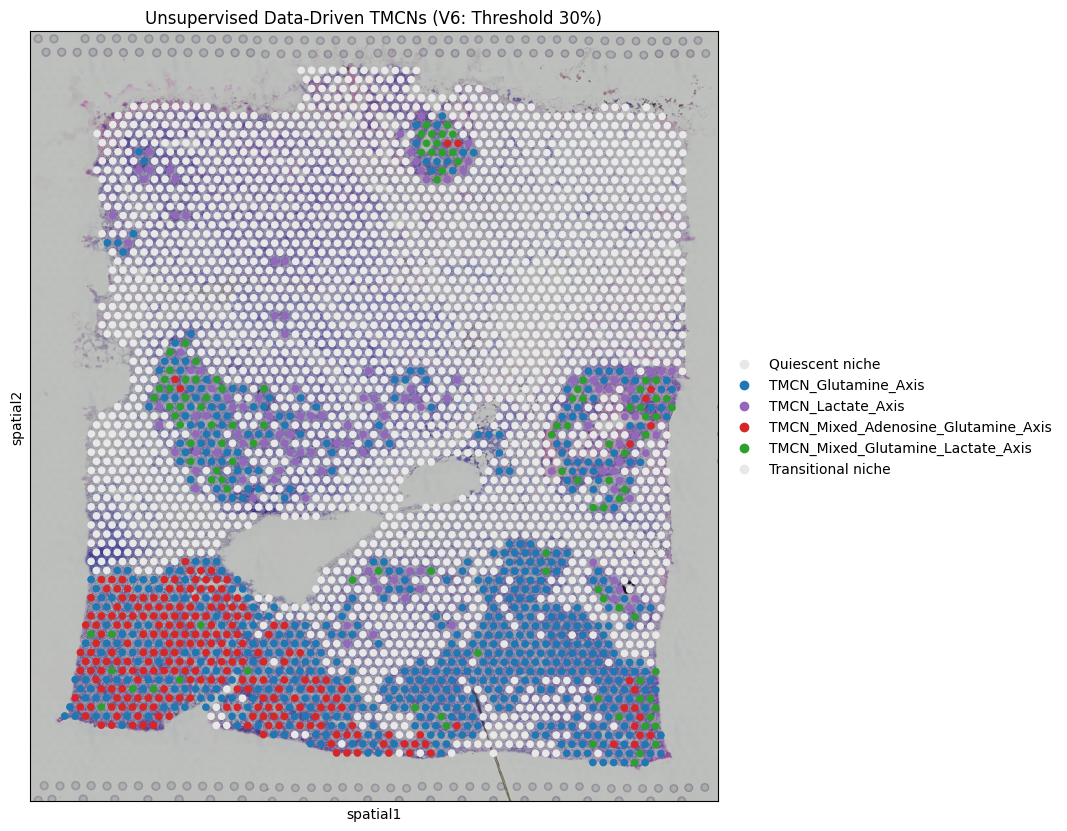

In [3]:
# ===== Notebook Cell 18 =====
# ===== Cell 8: latent 聚类 + 候选生态位骨架识别（Step 4-6）=====

print("===== 检查 adata_model =====")
print(adata_model)
print("adata_model.layers keys:", list(adata_model.layers.keys()))
print("has counts:", "counts" in adata_model.layers)
print("obsp keys:", list(adata_model.obsp.keys()))

# 1. 获取 latent 表示
adata_model.obsm["tmcn_latent"] = model.get_latent_representation(
    adata=adata_model,
    counts_key=None,
    adj_key="tmcn_connectivities",
    node_batch_size=128 if FAST_DEBUG else 256
)

# 2. 在 latent 空间构图
sc.pp.neighbors(
    adata_model,
    use_rep="tmcn_latent",
    key_added="tmcn_latent_neighbors"
)

# 3. Leiden 聚类：这些是候选生态位骨架的小 cluster
sc.tl.leiden(
    adata_model,
    neighbors_key="tmcn_latent_neighbors",
    key_added="TMCN_Clusters",
    resolution=0.8
)

print("===== 候选骨架 cluster 数量 =====")
print(adata_model.obs["TMCN_Clusters"].nunique())

# 4. 计算 spot-level role 阈值
thresholds = get_quantile_thresholds(
    adata_model,
    axes=AXES,
    sender_q=0.80,
    receiver_q=0.80
)

print("===== Spot-level role thresholds =====")
for axis, thr in thresholds.items():
    print(axis, thr)

# 5. 给每个 spot 在每条 axis 上赋角色
adata_model = assign_spot_roles_by_axis(
    adata_model,
    axes=AXES,
    thresholds=thresholds
)

# 6. 在 cluster 内统计代谢轴构成（Step 5）
df_cluster_axis_summary_v3 = build_cluster_axis_summary_v3(
    adata_model,
    axes=AXES,
    cluster_key="TMCN_Clusters",
    spatial_adj_key="spatial_connectivities",
    sender_high_q=0.90,
    receiver_high_q=0.90,
    coupling_high_q=0.90
)

# 7. cluster 级命名候选生态位（Step 6）
adata_model, df_cluster_annotation_v3 = assign_candidate_niches_v3(
    adata_model,
    df_cluster_axis_summary=df_cluster_axis_summary_v3,
    cluster_key="TMCN_Clusters",
    low_activity_threshold=0.05,
    formal_niche_threshold=0.14,
    mixed_margin=0.03,
    min_lcc_ratio=0.50
)

print("\n===== 候选生态位标签分布 =====")
print(adata_model.obs["TMCN_Candidate_Niche"].value_counts())

print("\n===== 候选生态位主轴分布 =====")
print(adata_model.obs["TMCN_Main_Axis_v3"].value_counts())

print("\n===== 候选生态位模式分布 =====")
print(adata_model.obs["TMCN_Niche_Pattern_v3"].value_counts())

print("\n===== cluster 级别总览 =====")
display(
    df_cluster_annotation_v3[
        ["Cluster", "Best_Axis", "Best_Score", "Second_Axis", "Second_Score", "Score_Margin", "Assigned_Label", "Niche_Pattern"]
    ].drop_duplicates().sort_values(["Assigned_Label", "Best_Score"], ascending=[True, False]).reset_index(drop=True)
)

print("\n===== cluster × axis 详细表 =====")
display(
    df_cluster_axis_summary_v3.sort_values(
        ["Cluster", "Axis_Composition_Score"],
        ascending=[True, False]
    )
)

# ===== Notebook Cell 19 =====
# ===== Cell 9: Step 7-10（拆分、清理、后验评估、拓扑分析）=====

# Step 7: 对异质 cluster 做二次拆分
adata_model = refine_heterogeneous_clusters(
    adata_model,
    base_cluster_key="TMCN_Clusters",
    niche_key="TMCN_Candidate_Niche",
    latent_key="tmcn_latent",
    refine_labels=("TMCN_Mixed", "Transitional niche"),
    subcluster_resolution=0.35
)

print("===== 二次拆分后的 refined cluster 数量 =====")
print(adata_model.obs["TMCN_Refined_Cluster"].nunique())

# Step 8: 清理过小、孤立碎片区域
adata_model = clean_small_spatial_fragments(
    adata_model,
    label_key="TMCN_Candidate_Niche",
    spatial_adj_key="spatial_connectivities",
    min_component_size=20,
    fallback_label="Transitional niche"
)

print("\n===== 连通区域清理后的候选生态位标签 =====")
print(adata_model.obs["TMCN_Candidate_Niche_Clean"].value_counts())

# ===== Notebook Cell 20 =====
# Step 9: pathology 后验评估（不参与训练）
ct_count, ct_row, ct_col = posterior_pathology_evaluation(
    adata_model,
    niche_key="TMCN_Candidate_Niche_Clean",
    pathology_key="annot_type"
)

print("\n===== pathology × niche（计数表） =====")
display(ct_count)

print("\n===== pathology × niche（按 pathology 行归一化） =====")
display(ct_row)

print("\n===== pathology × niche（按 niche 列归一化） =====")
display(ct_col)

# 后解释：如果 Quiescent niche 与 Healthy pathology 一致度高，则重命名为 Healthy niche
adata_model = posterior_rename_quiescent_to_healthy_if_supported(
    adata_model,
    niche_key="TMCN_Candidate_Niche_Clean",
    pathology_key="annot_type",
    healthy_label_name="Healthy niche",
    quiescent_label_name="Quiescent niche",
    min_healthy_purity=0.60
)

print("\n===== 最终生态位标签 =====")
print(adata_model.obs["TMCN_Final_Niche"].value_counts())

# Step 10: 网络拓扑分析
df_topology = compute_niche_topology_summary(
    adata_model,
    axes=AXES,
    final_niche_key="TMCN_Final_Niche",
    graph_key="tmcn_connectivities",
    pathology_key="annot_type"
)

print("\n===== 最终生态位拓扑分析 =====")
display(df_topology)

# ===== Notebook Cell 21 =====
# ===== 新增 Cell A：检查当前关键列 =====
required_cols = [
    "TMCN_Refined_Cluster",
    "TMCN_Main_Axis_v3",
    "tmcn_weighted_degree",
]

for col in required_cols:
    print(col, "=>", col in adata_model.obs.columns)

print("\n当前 obs 里和 TMCN 相关的列：")
for c in adata_model.obs.columns:
    if "TMCN" in c or "tmcn" in c:
        print(c)
        

# =========================================================
# 纯无监督版 Cell C：基于独立比例的生态位鉴定 (V6 科学富集版)
# 彻底废除病理学依赖，基于统计学富集度(>30%)进行判定
# =========================================================
import numpy as np
import pandas as pd

def assign_niche_pure_unsupervised(
    adata, 
    axes, 
    cluster_key="TMCN_Refined_Cluster", 
    global_high_quantile=0.75, # 全局前 25% 定义为 Active Spot (期望随机比例为 0.25)
    dominant_frac_thr=0.30,    # 【核心调优】Cluster内比例 > 0.30 即可视为显著富集主导
    quiescent_frac_thr=0.15    # Cluster内所有比例 < 0.15 视为休眠/健康背景
):
    print(f"正在计算每个代谢轴的 Active 阈值 (全局 Top {100-global_high_quantile*100:.0f}%)...")
    
    # 1. 独立计算每个 Spot 的各轴 Active 状态
    for ax in axes:
        coupling = adata.obs[f"{ax}_Sender_Score"] * adata.obs[f"{ax}_Receiver_Score"]
        adata.obs[f"{ax}_Coupling_Score"] = coupling
        
        pos_vals = coupling[coupling > 1e-6]
        thr = pos_vals.quantile(global_high_quantile) if len(pos_vals) > 0 else np.inf
        adata.obs[f"{ax}_is_Active"] = coupling >= thr

    # 2. 统计每个 Cluster 的活跃比例
    clusters = adata.obs[cluster_key].unique()
    rows =[]
    
    for cluster in clusters:
        idx = adata.obs[cluster_key] == cluster
        n_spots = idx.sum()
        if n_spots == 0: continue
            
        fracs = {ax: adata.obs.loc[idx, f"{ax}_is_Active"].mean() for ax in axes}
        sorted_fracs = sorted(fracs.items(), key=lambda x: x[1], reverse=True)
        top1_ax, top1_f = sorted_fracs[0]
        top2_ax, top2_f = sorted_fracs[1] if len(sorted_fracs) > 1 else ("None", 0.0)
        
        # 3. 纯数据驱动分类逻辑
        if top1_f < quiescent_frac_thr:
            label = "Quiescent niche"  # 统一叫休眠区，不再乱扣Healthy帽子
        elif top1_f < dominant_frac_thr:
            label = "Transitional niche"
        else:
            # 找出所有达到富集标准(>30%)的轴
            dominant_axes =[ax for ax, f in sorted_fracs if f >= dominant_frac_thr]
            
            if len(dominant_axes) == 1:
                label = f"TMCN_{dominant_axes[0]}_Axis" # 恭喜单轴回归！
            else:
                # 多个轴同时高度活跃，取前两个最强的定义为Mixed
                ax1, ax2 = dominant_axes[0], dominant_axes[1]
                pair = sorted([ax1, ax2])
                label = f"TMCN_Mixed_{pair[0]}_{pair[1]}_Axis"
                
        rows.append({
            "Refined_Cluster": cluster,
            "N_Spots": n_spots,
            "Top1_Axis": top1_ax,
            "Top1_Active_Frac": top1_f,
            "Top2_Axis": top2_ax,
            "Top2_Active_Frac": top2_f,
            "Final_Niche_Label": label
        })
        
    df_res = pd.DataFrame(rows).set_index("Refined_Cluster")
    
    # 4. 映射回 adata
    adata.obs["TMCN_Final_Niche_v6"] = adata.obs[cluster_key].map(df_res["Final_Niche_Label"].to_dict())
    return df_res

# 执行纯无监督鉴定
df_niche_summary_v6 = assign_niche_pure_unsupervised(
    adata_model, 
    axes=AXES, 
    cluster_key="TMCN_Refined_Cluster",
    global_high_quantile=0.75, 
    dominant_frac_thr=0.30,   # 降到0.30，找回那些被错杀的肿瘤核心！
    quiescent_frac_thr=0.15    
)

print("\n===== V6 纯无监督标签分布 (肿瘤核心应大幅回归) =====")
print(adata_model.obs["TMCN_Final_Niche_v6"].value_counts())

# =========================================================
# 专属可视化：隐藏背景区，点亮纯粹的数据驱动生态位
# =========================================================
import matplotlib.pyplot as plt
import scanpy as sc

plt.rcParams["figure.figsize"] = (10, 10)

unique_niches = adata_model.obs["TMCN_Final_Niche_v6"].dropna().unique()
color_palette = {}

# 定制高对比度颜色池 (专门分配给核心代谢轴)
colors =['#d62728', '#1f77b4', '#2ca02c', '#9467bd', '#ff7f0e', '#8c564b', '#e377c2', '#17becf']
c_idx = 0

for niche in unique_niches:
    niche_str = str(niche)
    # 将休眠区和过渡区隐身（浅灰色），完全基于数据特征
    if "Transitional" in niche_str or "Quiescent" in niche_str:
        color_palette[niche_str] = '#E8E8E8' 
    else:
        color_palette[niche_str] = colors[c_idx % len(colors)]
        c_idx += 1

print("正在绘制：纯无监督的肿瘤代谢空间分布图...")

sc.pl.spatial(
    adata_model,
    color="TMCN_Final_Niche_v6",
    palette=color_palette, 
    spot_size=200,
    title="Unsupervised Data-Driven TMCNs (V6: Threshold 30%)",
    show=True,
)
